In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch  as th
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy, time

np.set_printoptions(precision=4, suppress=True)
th.set_num_threads(max(1, th.get_num_threads()))

# Introduction
The SYNOP meteorological data can be found on [this site](https://public.opendatasoft.com); more details are available [on this page](https://public.opendatasoft.com/explore/dataset/donnees-synop-essentielles-omm/information/?sort=date). We use a prepared dataset containing a set of measurements (temperature, pressure, ...) taken every 3 hours at Orly airport. The objective is to predict the evolution of the weather! We start by building a simple model. The idea is to learn the weather of the next day.

## Reminder

Recurrent networks in *pytorch* expect as input a 3-dimensional tensor (*3D tensor*). The axes carry an important meaning:
- the first axis is the mini-batch
- the second one corresponds to "time"
- the third corresponds to the dimension of the input vectors (typically the embedding size or the number of input channels)


Therefore, a sequence of 5 vectors of 4 features (size 4) is represented as a tensor of dimensions (1,5,4). With 7 sequences of 5 vectors, all of size 4, we get (7,5,4) (side note: in some examples, the first two dimensions can be swapped).  

Let's start with some simple code on synthetic data. The goal is to "play" with the recurrent network, to understand the dimensions and how it works.


In [2]:
th.manual_seed(1) # To reproduce the experiments
inputs = th.randn((1,5,4))
print("input sequence :", inputs)
print("The shape : ", inputs.shape)

input sequence : tensor([[[-1.5256, -0.7502, -0.6540, -1.6095],
         [ 0.8657,  0.2444, -0.6629,  0.8073],
         [ 0.4391,  1.1712,  1.7674, -0.0954],
         [ 0.0612, -0.6177, -0.7981, -0.1316],
         [-0.7984,  0.3357,  0.2753,  1.7163]]])
The shape :  torch.Size([1, 5, 4])


# A simple recurrent model and LSTM

A simple recurrent network is for instance **nn.RNN**.
To build it, we must specify:
- the input size (this sets the size of the linear layer that processes the input vectors);
- the size of the hidden layer (this sets the size of the linear layer that processes the time transition).

Other useful options are available, like:
- nonlinearity
- bias
- batch_first


The forward function of a recurrent net can handle two types of input and therefore acts in two ways.

## One step forward
The first one corresponds to one time step: the neural network reads one input symbol and updates the hidden layer. The forward function therefore returns a tuple of two tensors: the output and the updated hidden layer.



In [3]:
recNN = nn.RNN(input_size=4, hidden_size=3,batch_first=True)  # Input dim is 4, hidden layer size  is 3

# initialize the hidden state.
# The hidden units initialisation must adapt to data dimensions,
# including the mini-batch dimension.
h0 = th.randn(1, 1, 3)
print("h0 : ",h0,h0.shape)

# One step
out, hn = recNN(inputs[0,0,:].view(1,1,-1), h0)
# The view is just to ensure 3 dimensions. Try without !
print("##################")
print("One step returns: ")
print("  1/  output : ", out, out.shape)
print("  2/  hidden : ", hn, hn.shape)
print("##################")

h0 :  tensor([[[-0.8737, -0.2693, -0.5124]]]) torch.Size([1, 1, 3])
##################
One step returns: 
  1/  output :  tensor([[[-0.6307, -0.0205,  0.0848]]], grad_fn=<TransposeBackward1>) torch.Size([1, 1, 3])
  2/  hidden :  tensor([[[-0.6307, -0.0205,  0.0848]]], grad_fn=<StackBackward0>) torch.Size([1, 1, 3])
##################


Both vectors are the same. Indeed, in a simple recurrent network there is no distinction between the output and the hidden layer. A prediction can be made at each time step from this hidden layer:

$$ h_t = f_1(x_t,h_{t-1})$$
$$ y_t = f_2(h_t)$$

For one step forward, the recurrent net only needs to keep track of the hidden layer. The more advanced **LSTM** cell uses two kinds of hidden layers: one for memory management, named the **cell state** ($c_t$), and one to make the prediction, named the **hidden state** ($h_t$). The API is almost the same for all recurrent nets and returns a tuple at each time step. This tuple gathers the data needed to unfold the network.

In [4]:
## LSTM
LSTM_NN = nn.LSTM(input_size=4, hidden_size=3, batch_first=True)  # Input dim is 4, hidden layer size  is 3
h0 =  th.randn(1, 1, 3) #
c0 =  th.randn(1, 1, 3) #
# One step

# One step
out, (hn,cn) = LSTM_NN(inputs[0,0,:].view(1,1,-1), (h0,c0))
print("##################")
print("One step returns: ")
print("  1/  output : ", out, out.shape)
print("  2/  hidden : ", hn, hn.shape)
print("  3/  cell   : ", cn, cn.shape)
print("##################")


##################
One step returns: 
  1/  output :  tensor([[[0.1313, 0.2055, 0.1265]]], grad_fn=<TransposeBackward0>) torch.Size([1, 1, 3])
  2/  hidden :  tensor([[[0.1313, 0.2055, 0.1265]]], grad_fn=<StackBackward0>) torch.Size([1, 1, 3])
  3/  cell   :  tensor([[[0.2867, 0.6155, 1.2126]]], grad_fn=<StackBackward0>) torch.Size([1, 1, 3])
##################


## Sequence forward (unfold)
The second "style" of the forward function consists in taking as input a sequence and to unfold the network on this input sequence. It is equivalent to a for loop.

In [5]:
# Process the whole sequence in one call: unfolding the network
outputs, hn = recNN(inputs, h0)
print("* outputs:\n",outputs, "\n  shape:",outputs.shape,"\n")
print("* hn:\n",hn, "\n  shape:",hn.shape)

* outputs:
 tensor([[[-0.9468,  0.0145,  0.7554],
         [-0.7556,  0.7759,  0.1204],
         [-0.1745,  0.9552,  0.1067],
         [-0.7262,  0.7153,  0.7108],
         [-0.9568,  0.5700,  0.7502]]], grad_fn=<TransposeBackward1>) 
  shape: torch.Size([1, 5, 3]) 

* hn:
 tensor([[[-0.9568,  0.5700,  0.7502]]], grad_fn=<StackBackward0>) 
  shape: torch.Size([1, 1, 3])


In this case, the forward function returns:
- the sequence of hidden layers associated with each input vector;
- and the last hidden layer.
The previous code is to some extent equivalent to this one:

In [6]:
hn=h0 # init
for t in range(inputs.shape[1]):
    out, hn = recNN(inputs[0,t].view(1,1,-1), hn)
    print("at time ",t, " out = ", out)

at time  0  out =  tensor([[[-0.9468,  0.0145,  0.7554]]], grad_fn=<TransposeBackward1>)
at time  1  out =  tensor([[[-0.7556,  0.7759,  0.1204]]], grad_fn=<TransposeBackward1>)
at time  2  out =  tensor([[[-0.1745,  0.9552,  0.1067]]], grad_fn=<TransposeBackward1>)
at time  3  out =  tensor([[[-0.7262,  0.7153,  0.7108]]], grad_fn=<TransposeBackward1>)
at time  4  out =  tensor([[[-0.9568,  0.5700,  0.7502]]], grad_fn=<TransposeBackward1>)


# Usage of GRU and LSTM

## GRU (Gated Recurrent Unit)

A **GRU** (Gated Recurrent Unit) is a recurrent neural network cell designed to improve over vanilla RNNs when modeling **long-term dependencies**.  
It introduces **gates** (learned soft switches) that control how much past information should be kept and how much new information should be injected.

### GRU state

A GRU has a **single** internal state:

- **hidden state**: $h_t \in \mathbb{R}^{H}$

### GRU equations

Given an input $x_t$ and the previous hidden state $h_{t-1}$:

- **Update gate**
$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)
$$

- **Reset gate**
$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)
$$

- **Candidate hidden state**
$$
\tilde{h}_t = \tanh\!\left(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h\right)
$$

- **New hidden state**
$$
h_t = (1 - z_t)\odot h_{t-1} + z_t \odot \tilde{h}_t
$$

### Intuition

- The **update gate** $z_t$ controls *how much we overwrite* the previous hidden state:
  - $z_t \approx 0$: keep the old memory
  - $z_t \approx 1$: replace it with the new candidate state

- The **reset gate** $r_t$ controls *how much past information* is used to build the candidate:
  - $r_t \approx 0$: ignore the past (fresh start)
  - $r_t \approx 1$: fully use the past

### In PyTorch

A GRU returns:

- `outputs`: all hidden states $(h_1, \dots, h_T)$
- `hn`: final hidden state $(h_T)$

```python
outputs, hn = nn.GRU(...)(inputs, h0)
```


## LSTM (Long Short-Term Memory)

An **LSTM** (Long Short-Term Memory) is a gated recurrent network that is especially effective for **long-term dependencies**.  
Compared to a GRU, it introduces a second internal state called the **cell state**, which acts as a dedicated long-term memory.

### LSTM states

An LSTM maintains **two** internal states:

- **hidden state**: $h_t \in \mathbb{R}^{H}$ (what the model outputs at each step)
- **cell state**: $c_t \in \mathbb{R}^{H}$ (long-term memory)

### LSTM equations

Given an input $x_t$, previous hidden state $h_{t-1}$, and previous cell state $c_{t-1}$:

- **Input gate**
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

- **Forget gate**
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

- **Output gate**
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

- **Candidate cell content**
$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

- **New cell state**
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

- **New hidden state**
$$
h_t = o_t \odot \tanh(c_t)
$$

### Intuition

- The **forget gate** $f_t$ decides what fraction of the *old memory* to keep.
- The **input gate** $i_t$ decides how much *new information* enters the memory.
- The **output gate** $o_t$ decides how much of the memory is exposed as the hidden state $h_t$.

The main benefit: the cell state $c_t$ can carry information over long sequences with less degradation than a vanilla RNN.

### In PyTorch

An LSTM returns:

- `outputs`: all hidden states $(h_1, \dots, h_T)$
- `hn`: final hidden state $(h_T)$
- `cn`: final cell state $(c_T)$

```python
outputs, (hn, cn) = nn.LSTM(...)(inputs, (h0, c0))
```


## Recap: RNN vs GRU vs LSTM

| Model | Internal states | Gating? | Long-term dependencies | PyTorch call |
|------:|------------------|:------:|:------------------------|--------------|
| **RNN** | $h_t$ | No | Difficult | `outputs, hn = recNN(inputs, h0)` |
| **GRU** | $h_t$ | Yes | Better | `outputs, hn = gru(inputs, h0)` |
| **LSTM** | $h_t, c_t$ | Yes | Strong (classic) | `outputs, (hn, cn) = lstm(inputs, (h0, c0))` |

### Practical note (important!)

- **GRU** uses only a hidden state $h_t$, so the initial state is just `h0`.
- **LSTM** needs **two** initial states: `h0` (hidden) **and** `c0` (cell).

This is why LSTM calls in PyTorch look different from RNN/GRU calls.


---

## TODO (GRU & LSTM)

- [ ] Replace the RNN with a **GRU** and run the same code.
- [ ] Replace the GRU with an **LSTM** and run the same code.
- [ ] Print and compare the output shapes (`outputs`, `hn`, and `cn` for LSTM).

---


In [7]:
## GRU
th.manual_seed(1)
gru = nn.GRU(input_size=4, hidden_size=3, batch_first=True)
h0 = th.randn(1, 1, 3)

# One step: same call as for nn.RNN
out, hn = gru(inputs[0, 0, :].view(1, 1, -1), h0)
print("One step -> output:", tuple(out.shape), "| hidden:", tuple(hn.shape))

# Full sequence (unfolding the network)
outputs, hn = gru(inputs, h0)
print("Sequence -> outputs:", tuple(outputs.shape), "| hn:", tuple(hn.shape))
print("The last output is the final hidden state:", th.allclose(outputs[:, -1], hn[0]))

One step -> output: (1, 1, 3) | hidden: (1, 1, 3)
Sequence -> outputs: (1, 5, 3) | hn: (1, 1, 3)
The last output is the final hidden state: True


In [8]:
## LSTM
th.manual_seed(1)
lstm = nn.LSTM(input_size=4, hidden_size=3, batch_first=True)
h0 = th.randn(1, 1, 3)
c0 = th.randn(1, 1, 3)

# Full sequence: the initial state is a tuple (h0, c0)
outputs, (hn, cn) = lstm(inputs, (h0, c0))
print("outputs:", tuple(outputs.shape), "| hn:", tuple(hn.shape), "| cn:", tuple(cn.shape))
print("The last output is hn:", th.allclose(outputs[:, -1], hn[0]))
print("... but not cn:        ", th.allclose(outputs[:, -1], cn[0]))

# Number of parameters: 1, 3 then 4 blocks (W, U, bias) depending on the number of gates
for name, net in [("RNN", recNN), ("GRU", gru), ("LSTM", lstm)]:
    print(f"{name:4s}: {sum(p.numel() for p in net.parameters())} parameters")

outputs: (1, 5, 3) | hn: (1, 1, 3) | cn: (1, 1, 3)
The last output is hn: True
... but not cn:         False
RNN : 27 parameters
GRU : 81 parameters
LSTM: 108 parameters


**Comparison.** The three networks return the same output shape: `outputs` has size (1, 5, 3), i.e. (batch, time, hidden size), and contains the hidden state $h_t$ at each step; its last row matches `hn`. Two differences to remember:

- the LSTM takes and returns a **tuple** `(h, c)`; `outputs` only contains the $h_t$, and the memory $c_t$ is only available for the last step (`cn`);
- the `batch_first=True` option applies **only to inputs and outputs**: the states `hn` and `cn` keep the shape (number of layers, batch, hidden size), here (1, 1, 3).

The number of parameters reflects the number of affine transformations: 1 for the RNN (27 parameters), 3 for the GRU (update and reset gates, plus the candidate state: 81) and 4 for the LSTM (input, forget and output gates, plus the candidate content: 108).

# Dataset: weather forecast
The dataset comes from this [open data site](https://public.opendatasoft.com/explore/dataset/donnees-synop-essentielles-omm/table/?sort=date&refine.nom=ORLY). After filtering and feature selection, we keep the following features:  
- Sea-level pressure
- 3-hour pressure change
- Mean wind direction (10 min)
- Mean wind speed (10 min)
- Temperature
- Dew point
- Humidity


In [9]:
train = np.load("weather_train.npy",allow_pickle=True)
test  = np.load("weather_test.npy",allow_pickle=True)


---

## TODO

- [ ] Explore the data, look at the values, their respective scales, ... and create tensors with the useful part (the date can be skipped for pytorch).
- [ ] Given the different scales involved, it is more efficient to normalize the data: compute the mean and variance of each component on the training set and standardize the datasets.  

In [10]:
features = ["Sea-level pressure (Pa)", "3 h change (Pa)", "Wind direction (°)", "Wind speed (m/s)",
            "Temperature (K)", "Dew point (K)", "Humidity (%)"]
short = ["pressure", "3 h change", "direction", "speed", "temp.", "dew point", "humidity"]

dates_train = pd.to_datetime(train[:, 0], utc=True)
dates_test  = pd.to_datetime(test[:, 0], utc=True)
X_train = train[:, 1:].astype(np.float32)
X_test  = test[:, 1:].astype(np.float32)

print("Train:", X_train.shape, "from", dates_train[0].date(), "to", dates_train[-1].date())
print("Test: ", X_test.shape,  "from", dates_test[0].date(),  "to", dates_test[-1].date())
print("Missing values:", int(np.isnan(X_train).sum()), "(train),", int(np.isnan(X_test).sum()), "(test)")

def step_hours(dates):
    """Gap in hours between two consecutive measurements."""
    return np.diff(dates.values.astype("datetime64[s]").astype(np.int64)) / 3600

steps = pd.Series(step_hours(dates_train)).value_counts().sort_index()
print("Gaps between two measurements (hours -> count):", {float(k): int(v) for k, v in steps.items()})

stats = pd.DataFrame({"min": X_train.min(0), "mean": X_train.mean(0),
                      "std": X_train.std(0), "max": X_train.max(0)}, index=features)
display(stats.round(2))

Train: (30520, 7) from 2010-01-01 to 2020-06-18
Test:  (7631, 7) from 2020-06-18 to 2023-01-28
Missing values: 0 (train), 0 (test)
Gaps between two measurements (hours -> count): {3.0: 30477, 6.0: 36, 9.0: 4, 12.0: 2}


,min,mean,std,max
Sea-level pressure (Pa),97050.00,101691.656250,915.489990,104720.000000
3 h change (Pa),-1000.00,0.080000,125.160004,1240.000000
Wind direction (°),0.00,183.919998,104.440002,360.000000
Wind speed (m/s),0.00,3.480000,2.000000,15.900000
Temperature (K),260.75,285.220001,7.240000,314.549988
Dew point (K),253.25,280.269989,5.540000,295.750000
Humidity (%),15.00,74.570000,17.660000,100.000000


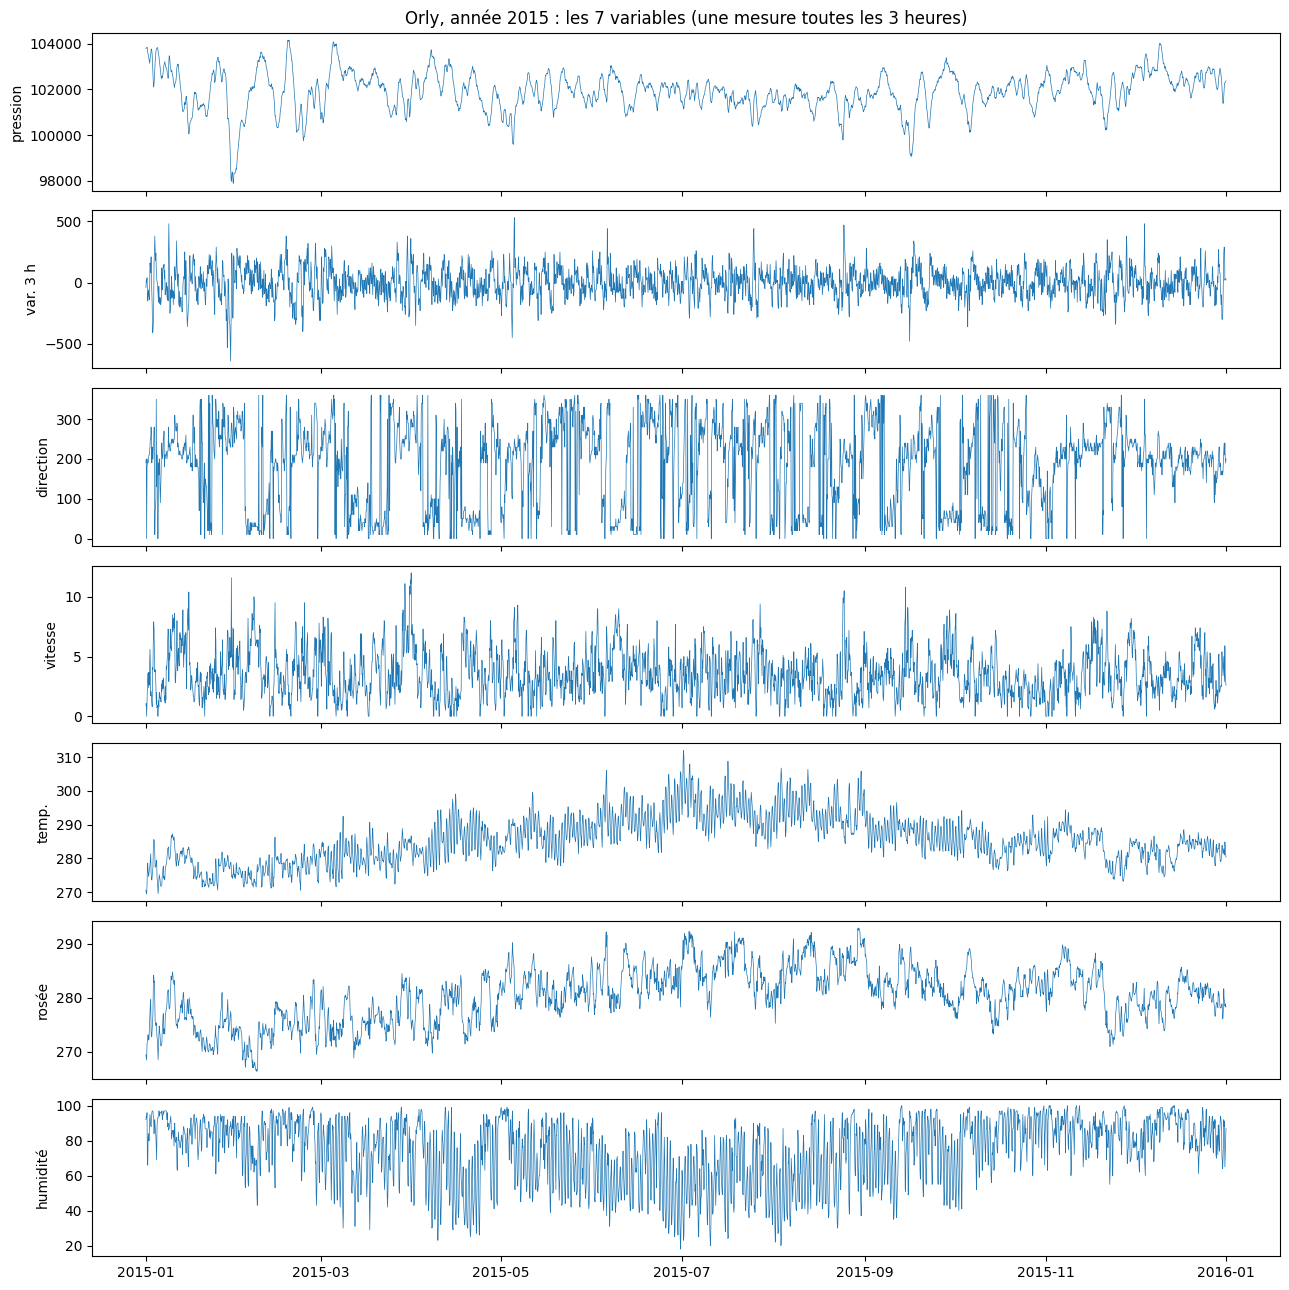

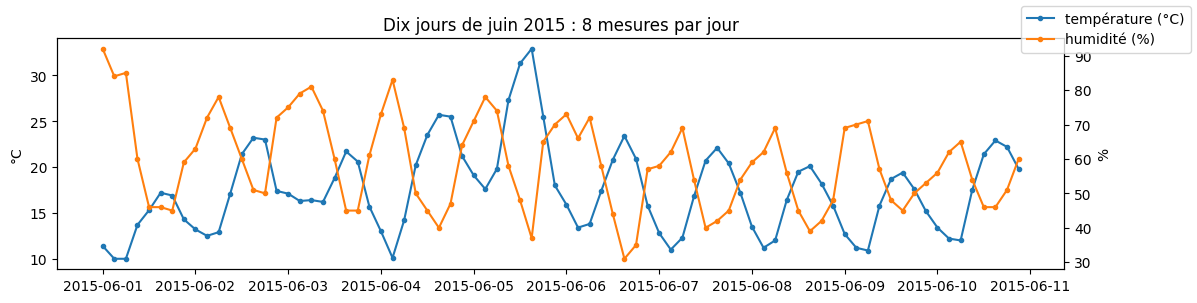

In [11]:
# One year of measurements to see the scales and the cycles
year = (dates_train >= "2015-01-01") & (dates_train < "2016-01-01")
fig, axes = plt.subplots(7, 1, figsize=(13, 13), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(dates_train[year], X_train[year, k], lw=0.5)
    ax.set_ylabel(short[k])
axes[0].set_title("Orly, 2015: the 7 variables (one measurement every 3 hours)")
plt.tight_layout()
plt.show()

# Zoom on 10 days: daily cycle of temperature and humidity
days = (dates_train >= "2015-06-01") & (dates_train < "2015-06-11")
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(dates_train[days], X_train[days, 4] - 273.15, "o-", ms=3, label="temperature (°C)")
ax2 = ax.twinx()
ax2.plot(dates_train[days], X_train[days, 6], "o-", ms=3, color="C1", label="humidity (%)")
ax.set_ylabel("°C"); ax2.set_ylabel("%")
ax.set_title("Ten days in June 2015: 8 measurements per day")
fig.legend(loc="upper right")
plt.show()

In [12]:
# Normalization: mean and standard deviation computed on the training set only, applied to both sets
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
Z_train = (X_train - mean) / std
Z_test  = (X_test  - mean) / std

T_train = th.tensor(Z_train)
T_test  = th.tensor(Z_test)
print("Tensors:", tuple(T_train.shape), tuple(T_test.shape))
print("Normalized train: means", T_train.mean(0).numpy().round(3), "| stds", T_train.std(0).numpy().round(3))
print("Normalized test:  means", T_test.mean(0).numpy().round(3), "| stds", T_test.std(0).numpy().round(3))

Tensors: (30520, 7) (7631, 7)
Normalized train: means [ 0.  0. -0.  0. -0.  0.  0.] | stds [1. 1. 1. 1. 1. 1. 1.]
Normalized test:  means [ 0.052  0.001 -0.009  0.062  0.143  0.134 -0.04 ] | stds [0.983 0.984 0.984 0.975 1.031 0.985 1.061]


**Observations.**

- Measurements are taken **every 3 hours** (8 per day), from January 2010 to June 2020 for the training set and from June 2020 to January 2023 for the test set, which therefore directly extends the training set in time. There are no missing values, but the series has a few gaps (about forty gaps of 6 to 12 h in the training set) that must be avoided inside a sequence.
- The **scales are very different**: pressure is about $10^5$ Pa with a standard deviation of 900 Pa, whereas wind speed is a few m/s. Without normalization, the quadratic loss would be dominated by pressure and pressure change, and optimization would be ill-conditioned. Each variable is centered and scaled with the mean and standard deviation **of the training set** (applying them to the test set avoids any information leakage): the normalized test set indeed has means close to 0 and standard deviations close to 1.
- Temperature, dew point and humidity follow an **annual cycle** and a strong **daily cycle** (period of 8 steps); pressure varies more slowly, with the passing weather systems.
- Wind direction is an **angle**: 0° and 360° are the same direction, which linear normalization ignores. We keep the 7 variables required by the assignment here; a (cos, sin) encoding would be a natural improvement.

## Reshaping the data

We want to train the recurrent network with mini-batches of size *bsz*. To keep things simple, all the sequences in a mini-batch have the same length: *ls=16* time steps.

---

## TODO

- [ ] write a function that takes the training data and turns it into a tensor of size (B,L=16,7);
- [ ] test it to make sure everything is correct (for instance by plotting some parts).

In [13]:
L = 16

def make_sequences(data, dates=None, L=16, stride=None):
    """Splits a series (N, 7) into a tensor of sequences (B, L, 7).

    stride = L (default): disjoint sequences, equivalent to a simple reshape.
    stride < L: overlapping sliding windows.
    dates: if provided, windows containing a measurement gap are discarded
    (a gap other than 3 h between two consecutive steps)."""
    if stride is None:
        stride = L
    data = np.asarray(data, dtype=np.float32)
    starts = np.arange(0, len(data) - L + 1, stride)
    if dates is not None:
        gap = (step_hours(dates) != 3).astype(int)
        # a window starting at s uses the transitions s, ..., s + L - 2
        bad = np.convolve(gap, np.ones(L - 1, dtype=int), mode="valid") > 0
        starts = starts[~bad[starts]]
    idx = starts[:, None] + np.arange(L)
    return th.tensor(data[idx])

# Checks
seqs = make_sequences(Z_train, L=L)
B = len(Z_train) // L
print("Disjoint sequences:", tuple(seqs.shape))
print("Identical to a reshape:", th.equal(seqs, T_train[:B * L].reshape(B, L, 7)))
print("First sequence = first 16 measurements:", th.equal(seqs[0], T_train[:L]))
seqs_clean = make_sequences(Z_train, dates_train, L=L, stride=1)
print("Sliding windows:", len(Z_train) - L + 1, "possible,", len(seqs_clean), "without a measurement gap")

Disjoint sequences: (1907, 16, 7)
Identical to a reshape: True
First sequence = first 16 measurements: True
Sliding windows: 30505 possible, 29881 without a measurement gap


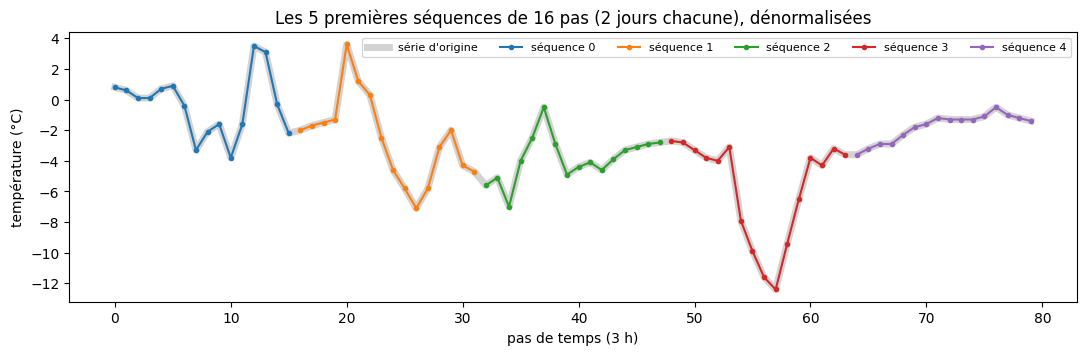

In [14]:
# Sequences stitched end to end must give back the original series
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(np.arange(5 * L), X_train[:5 * L, 4] - 273.15, color="lightgray", lw=5, label="original series")
for b in range(5):
    temp = seqs[b, :, 4].numpy() * std[4] + mean[4] - 273.15
    ax.plot(np.arange(b * L, (b + 1) * L), temp, "o-", ms=3, label=f"sequence {b}")
ax.set_xlabel("time step (3 h)"); ax.set_ylabel("temperature (°C)")
ax.set_title("The first 5 sequences of 16 steps (2 days each), denormalized")
ax.legend(ncol=6, fontsize=8)
plt.show()

In [15]:
# Datasets used for training
# - validation: the most recent 10% of the training set (chronological split, no overlap with training)
# - training: sliding windows of 16 steps (stride 1) to multiply the examples
# - test: disjoint sequences of 16 steps, kept for the final evaluation
cut = int(0.9 * len(Z_train))
train_seq = make_sequences(Z_train[:cut], dates_train[:cut], L=L, stride=1)
valid_seq = make_sequences(Z_train[cut:], dates_train[cut:], L=L, stride=L)
test_seq  = make_sequences(Z_test, dates_test, L=L, stride=L)
print("training:", tuple(train_seq.shape), "| validation:", tuple(valid_seq.shape), "| test:", tuple(test_seq.shape))
print("Validation starts on", dates_train[cut].date())

training: (26889, 16, 7) | validation: (187, 16, 7) | test: (471, 16, 7)
Validation starts on 2019-06-02


**Choices.** A sequence of 16 steps covers **2 days**. The `make_sequences` function produces either disjoint sequences (identical to a simple `reshape`, as the checks confirm) or sliding windows. For training, we use sliding windows, which give about 16 times more examples from the same data, discarding those that overlap a measurement gap. Validation uses the most recent 10% of the training set, with a **chronological** split: a random split would mix neighboring, almost identical windows between training and validation. The test set is kept for the final evaluation.

# Recurrent model
The idea is to train a recurrent model that can predict the weather of the next day given the past observations.
To learn the model, we use sequences of length 16.

## Putting the pieces together
To set everything up, we can first play with each component on a toy batch.

The first network is composed of:
- a GRU cell
- a linear output layer

---

## TODO

- [ ] fill the cell below with a GRU cell and a linear layer. It should work!


In [16]:
# A GRU followed by a linear layer, on a small batch
th.manual_seed(1)
bsz, H = 4, 10
batch = train_seq[:bsz]                          # (4, 16, 7)
gru = nn.GRU(input_size=7, hidden_size=H, batch_first=True)
lin = nn.Linear(H, 7)

h0 = th.zeros(1, bsz, H)
outputs, hn = gru(batch[:, :-1], h0)             # reads the first 15 steps
preds = lin(outputs)                             # one prediction per time step
target = batch[:, 1:]                            # target: the same sequence shifted by one step
print("input:", tuple(batch[:, :-1].shape), "| GRU outputs:", tuple(outputs.shape),
      "| predictions:", tuple(preds.shape), "| target:", tuple(target.shape))
print("MSE before training:", F.mse_loss(preds, target).item())

input:

 (4, 15, 7) | GRU outputs: (4, 15, 10) | predictions: (4, 15, 7) | target: (4, 15, 7)
MSE before training: 2.0013608932495117


The linear layer applies to the last axis, hence to every time step: at each time $t$, the model produces a vector of 7 values that is compared with the observation $x_{t+1}$. The network is thus trained to predict **the next measurement (3 h later)** from everything it has read so far. Forecasting "the next day" then amounts to chaining 8 predictions, which is the topic of the long-term forecasting section.

## Build your own module

Writing your own module is easy in pytorch, and it wraps what you have seen so far. To debug the model, you can first play step by step with each layer to make sure the dimensions are right (as done above). Then write the class and run the training to evaluate the result (which is what we do now).

The class inherits from an existing pytorch class, Module: your class is a Module, with some specific additions. The two most important parts are the constructor and the forward method.

In [17]:
class GRUPredictor(nn.Module):
    """GRUPredictor is a recurrent model. It takes as input a vector and predict
    the next one given past observations."""
    def __init__(self, input_dim=7, hidden_dim=50, nstack = 1, dropout=0):
        super(GRUPredictor, self).__init__()
        self.idim = input_dim
        self.hdim = hidden_dim
        self.nstack = nstack
        # nstack > 1: stacked GRUs; dropout only applies between two layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=nstack, batch_first=True,
                          dropout=dropout if nstack > 1 else 0)
        self.out = nn.Linear(hidden_dim, input_dim)
        self.h = None

    def init_hidden(self, bsz):
        # This function is given: understand it.
        self.h = th.zeros(self.nstack, bsz, self.hdim)

    def forward(self, inputs, h0=None):
        """inputs: (B, T, input_dim). Returns the next-step predictions (B, T, input_dim)
        and the final hidden state (nstack, B, hidden_dim)."""
        if h0 is None:
            self.init_hidden(inputs.shape[0])
            h0 = self.h
        outputs, hn = self.gru(inputs, h0)
        return self.out(outputs), hn

In [18]:
# A simple test of the model on a mini-batch
th.manual_seed(1)
model = GRUPredictor(hidden_dim=10)
preds, hn = model(batch[:, :-1])
print("predictions:", tuple(preds.shape), "| final state:", tuple(hn.shape))
print("parameters:", sum(p.numel() for p in model.parameters()))
print("MSE :", F.mse_loss(preds, batch[:, 1:]).item())

predictions: (4, 15, 7) | final state: (1, 4, 10)
parameters: 647
MSE : 2.0013608932495117


# A first forecasting model: training and evaluation

We now have everything. It is time to build a model and train it:
- select the loss function
- the optimizer can be Adam with a low initial learning rate (e.g. 1e-3 or 5e-4)
- the training algorithm processes mini-batches of e.g. 100 sequences (length 16 for each sequence)
- for validation monitoring, use the test set or take the last 10% of the sequences
- start with a hidden dimension of 10 and try higher values.



epoch   1 | train 0.6273 | valid 0.4511 | 1 s


epoch   6 | train 0.2623 | valid 0.2733 | 6 s


epoch  11 | train 0.2419 | valid 0.2532 | 10 s


epoch  16 | train 0.2342 | valid 0.2451 | 15 s


epoch  21 | train 0.2305 | valid 0.2410 | 19 s


epoch  26 | train 0.2286 | valid 0.2387 | 24 s


epoch  30 | train 0.2277 | valid 0.2383 | 28 s


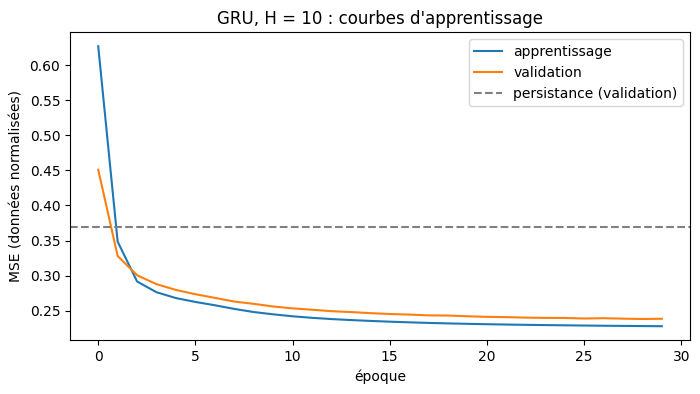

Best validation MSE: 0.2380 (persistence: 0.3687)


In [19]:
def evaluate(model, seqs, bsz=500):
    """MSE (normalized data) of the next-step prediction, with the true values as input."""
    model.eval()
    total = 0.0
    with th.no_grad():
        for i in range(0, len(seqs), bsz):
            b = seqs[i:i + bsz]
            preds, _ = model(b[:, :-1])
            total += F.mse_loss(preds, b[:, 1:], reduction="sum").item()
    return total / seqs[:, 1:].numel()

def train_model(model, train_seq, valid_seq, epochs=30, bsz=100, lr=1e-3, verbose=True):
    """Teacher-forcing training: at each step, the model reads the true value.
    The weights of the best epoch on the validation set are kept."""
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = {"train": [], "valid": []}
    best, best_state = float("inf"), None
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        perm = th.randperm(len(train_seq))
        total = 0.0
        for i in range(0, len(train_seq), bsz):
            b = train_seq[perm[i:i + bsz]]
            preds, _ = model(b[:, :-1])
            loss = F.mse_loss(preds, b[:, 1:])
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item() * len(b)
        hist["train"].append(total / len(train_seq))
        hist["valid"].append(evaluate(model, valid_seq))
        if hist["valid"][-1] < best:
            best, best_state = hist["valid"][-1], copy.deepcopy(model.state_dict())
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f"epoch {ep + 1:3d} | train {hist['train'][-1]:.4f} | valid {hist['valid'][-1]:.4f} | {time.time() - t0:.0f} s")
    model.load_state_dict(best_state)
    return hist

def persistence_mse(seqs):
    """Naive baseline: predict that the next measurement equals the current one."""
    return F.mse_loss(seqs[:, :-1], seqs[:, 1:]).item()

th.manual_seed(1)
model = GRUPredictor(hidden_dim=10)
hist = train_model(model, train_seq, valid_seq, epochs=30, lr=1e-3)

plt.figure(figsize=(8, 4))
plt.plot(hist["train"], label="training")
plt.plot(hist["valid"], label="validation")
plt.axhline(persistence_mse(valid_seq), color="gray", ls="--", label="persistence (validation)")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized data)")
plt.title("GRU, H = 10: learning curves")
plt.legend()
plt.show()
print(f"Best validation MSE: {min(hist['valid']):.4f} (persistence: {persistence_mse(valid_seq):.4f})")

**Training.** The GRU with $H = 10$ (647 parameters) is trained with *teacher forcing*: at each step it reads the true measurement and must predict the next one, with a quadratic loss (MSE) on the normalized data. The loss drops quickly during the first 5 epochs, then plateaus: the best validation MSE is **0.238**, against **0.369** for persistence ("the next measurement will equal the current one"), i.e. an error reduced by about 35%. The training and validation curves stay close, so there is no overfitting at this size; the limit comes rather from the model's capacity and from the unpredictable part of the weather with only 7 measurements at a single location.

## Forecasting evaluation
Now that the model is trained, it can be used for forecasting. The first evaluation uses the same conditions as training: predict the 7 values of the next step given the true values observed so far.

---

## TODO

- [ ] compute the loss on the test set
- [ ] plot the prediction for 100 consecutive days


In [20]:
def to_physical(z):
    """Denormalizes (..., 7) and converts: pressure and pressure change to hPa, temperatures to °C."""
    x = z * th.tensor(std) + th.tensor(mean)
    x = x.clone()
    x[..., 0:2] /= 100
    x[..., 4:6] -= 273.15
    return x

units = ["hPa", "hPa", "°", "m/s", "°C", "°C", "%"]

def one_step_rmse(model, seqs):
    """Per-variable RMSE of the 3 h prediction, in physical units."""
    model.eval()
    with th.no_grad():
        preds, _ = model(seqs[:, :-1])
    err_model = to_physical(preds) - to_physical(seqs[:, 1:])
    err_pers  = to_physical(seqs[:, :-1]) - to_physical(seqs[:, 1:])
    rmse = lambda e: e.pow(2).mean(dim=(0, 1)).sqrt().numpy()
    return rmse(err_model), rmse(err_pers)

print(f"Test MSE (normalized): GRU {evaluate(model, test_seq):.4f} | persistence {persistence_mse(test_seq):.4f}")
r_model, r_pers = one_step_rmse(model, test_seq)
display(pd.DataFrame({"unit": units, "GRU RMSE": r_model.round(2), "persistence RMSE": r_pers.round(2)},
                     index=features).rename_axis("3 h forecast (test)"))

Test MSE (normalized): GRU 0.2268 | persistence 0.3526


,unit,GRU RMSE,persistence RMSE
3 h forecast (test),,,
Sea-level pressure (Pa),hPa,1.080000,1.260000
3 h change (Pa),hPa,0.800000,1.050000
Wind direction (°),°,74.459999,88.970001
Wind speed (m/s),m/s,1.210000,1.400000
Temperature (K),°C,1.690000,2.490000
Dew point (K),°C,1.230000,1.270000
Humidity (%),%,7.500000,10.540000


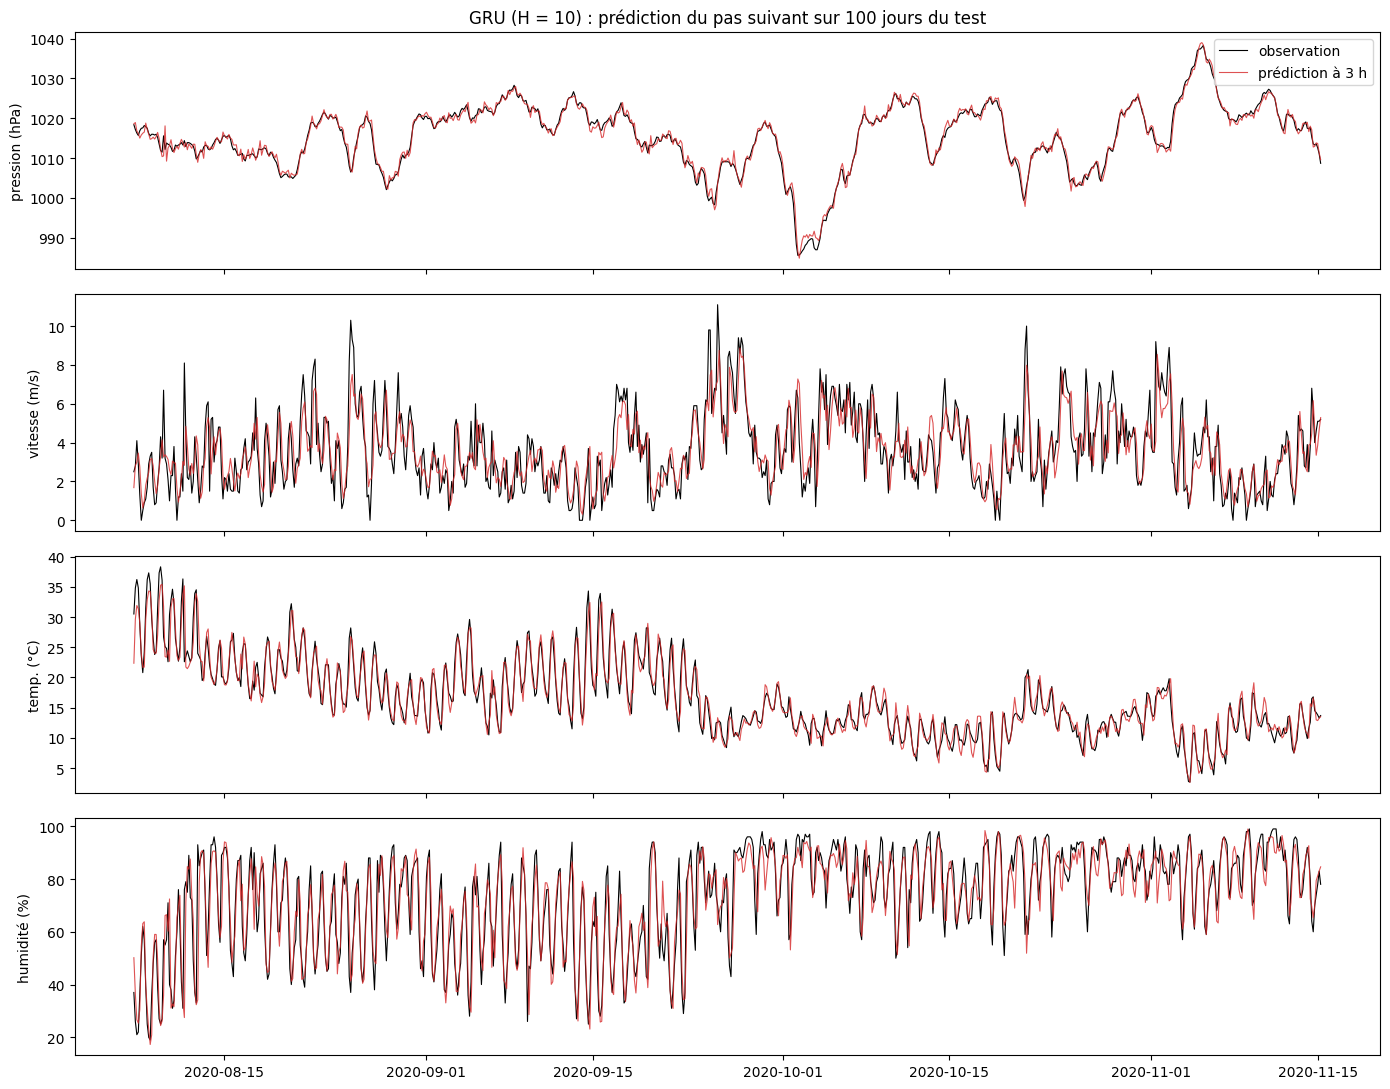

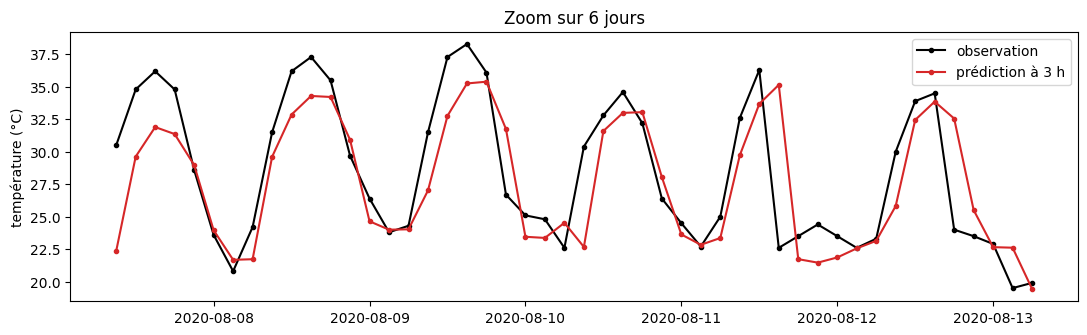

In [21]:
# 3 h predictions over 100 consecutive test days (800 steps):
# the model reads the true series and predicts the next measurement at each step
start, n = 400, 100 * 8
segment = T_test[start:start + n + 1].unsqueeze(0)
model.eval()
with th.no_grad():
    preds, _ = model(segment[:, :-1])
truth_phys = to_physical(segment[0, 1:]).numpy()
pred_phys = to_physical(preds[0]).numpy()
d = dates_test[start + 1:start + n + 1]

show = [0, 3, 4, 6]
fig, axes = plt.subplots(len(show), 1, figsize=(14, 11), sharex=True)
for ax, k in zip(axes, show):
    ax.plot(d, truth_phys[:, k], color="k", lw=0.8, label="observation")
    ax.plot(d, pred_phys[:, k], color="C3", lw=0.8, alpha=0.8, label="3 h prediction")
    ax.set_ylabel(f"{short[k]} ({units[k]})")
axes[0].legend(loc="upper right")
axes[0].set_title("GRU (H = 10): next-step prediction over 100 test days")
plt.tight_layout()
plt.show()

# Zoom on 6 days to see the details
z = slice(0, 48)
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(d[z], truth_phys[z, 4], "o-", color="k", ms=3, label="observation")
ax.plot(d[z], pred_phys[z, 4], "o-", color="C3", ms=3, label="3 h prediction")
ax.set_ylabel("temperature (°C)"); ax.legend()
ax.set_title("Zoom on 6 days")
plt.show()

**3 h evaluation.** On the test set, the MSE is **0.227** against 0.353 for persistence, consistent with the validation result. In physical units, the gain is clear for temperature (1.69 °C vs 2.49 °C) and humidity (7.5% vs 10.5%), which follow a daily cycle the model has learned; it is smaller for pressure (1.08 vs 1.26 hPa), which evolves slowly and is already well predicted by persistence, and almost zero for the dew point. Wind direction remains very poorly predicted (74°), both because it is noisy and because encoding it as a number between 0 and 360 is unsuitable.

Over the 100 plotted days, the predictions closely follow the pressure and the day-night cycle of temperature and humidity. Two flaws are visible: heat peaks are slightly underestimated and wind gusts are not anticipated. This is the expected behavior of a model trained with a quadratic loss, which predicts a mean value and smooths out extremes.

This evaluation remains **optimistic**: at each step, the model receives the true measurement. Forecasting "the next day" requires chaining 8 predictions, which the next section tests.

## Long-term forecasting

We can also evaluate long-term predictions: let the model "read" N=15 true values, then generate the N following values. For this generation step, the model uses its own predictions as new inputs.

---

## TODO

- [ ] add a method to the model class that "reads" an input sequence and then generates N samples
- [ ] test it with N=15 samples taken from the test data
- [ ] plot the predictions and the ground truth, along with the one-step predictions for visual comparison
- [ ] for a better evaluation, rescale the values.

Test windows (15 steps read + 15 to forecast): (1862, 30, 7)


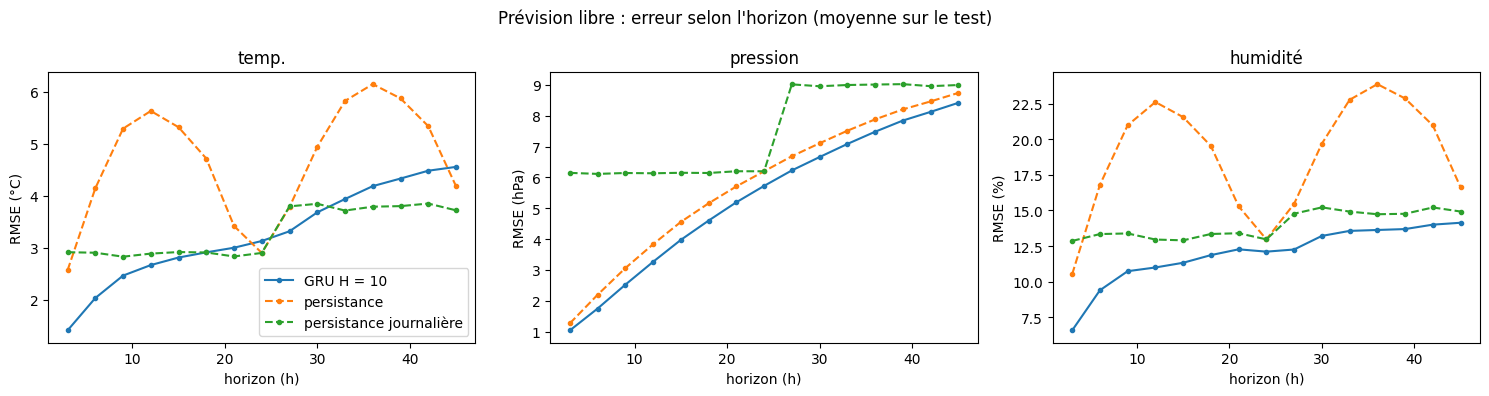

,GRU H = 10,persistence,daily persistence
temperature at 24 h (°C),3.13,2.90,2.90
temperature at 45 h (°C),4.56,4.19,3.72
pressure at 24 h (hPa),5.73,6.20,6.20
humidity at 24 h (%),12.11,12.97,12.97


In [22]:
@th.no_grad()
def generate(self, context, N):
    """Reads the context sequence (B, T, 7) with the true values, then generates N steps
    by feeding back its own prediction as the new input each time."""
    self.eval()
    preds, h = self(context)
    x = preds[:, -1:]                # prediction of step T + 1
    outputs = [x]
    for _ in range(N - 1):
        x, h = self(x, h)
        outputs.append(x)
    return th.cat(outputs, dim=1)    # (B, N, 7)

GRUPredictor.generate = generate

N_CTX, N_GEN = 15, 15
long_test = make_sequences(Z_test, dates_test, L=N_CTX + N_GEN, stride=4)
print("Test windows (15 steps read + 15 to forecast):", tuple(long_test.shape))

def horizon_rmse(pred, truth):
    """RMSE per horizon and per variable, in physical units: (N, 7)."""
    return (to_physical(pred) - to_physical(truth)).pow(2).mean(dim=0).sqrt().numpy()

def baselines(wins, n_ctx=N_CTX, N=N_GEN):
    """Persistence (last value repeated) and daily persistence (the last 8 steps repeated)."""
    ctx = wins[:, :n_ctx]
    persist = ctx[:, -1:].expand(-1, N, -1)
    daily = th.stack([ctx[:, n_ctx - 8 + (h % 8)] for h in range(N)], dim=1)
    return persist, daily

def free_run_rmse(model, wins, n_ctx=N_CTX, N=N_GEN):
    gen = model.generate(wins[:, :n_ctx], N)
    return horizon_rmse(gen, wins[:, n_ctx:n_ctx + N])

truth = long_test[:, N_CTX:]
persist, daily = baselines(long_test)
R = {"GRU H = 10": free_run_rmse(model, long_test),
     "persistence": horizon_rmse(persist, truth),
     "daily persistence": horizon_rmse(daily, truth)}

hours = 3 * np.arange(1, N_GEN + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [4, 0, 6]):
    for name, r in R.items():
        ax.plot(hours, r[:, k], marker="o", ms=3, label=name, ls="--" if "persistence" in name else "-")
    ax.set_xlabel("horizon (h)"); ax.set_ylabel(f"RMSE ({units[k]})"); ax.set_title(short[k])
axes[0].legend()
plt.suptitle("Free-running forecast: error vs horizon (mean over the test set)")
plt.tight_layout()
plt.show()

tab = pd.DataFrame({name: [r[7, 4], r[14, 4], r[7, 0], r[7, 6]] for name, r in R.items()},
                   index=["temperature at 24 h (°C)", "temperature at 45 h (°C)", "pressure at 24 h (hPa)", "humidity at 24 h (%)"])
display(tab.round(2))

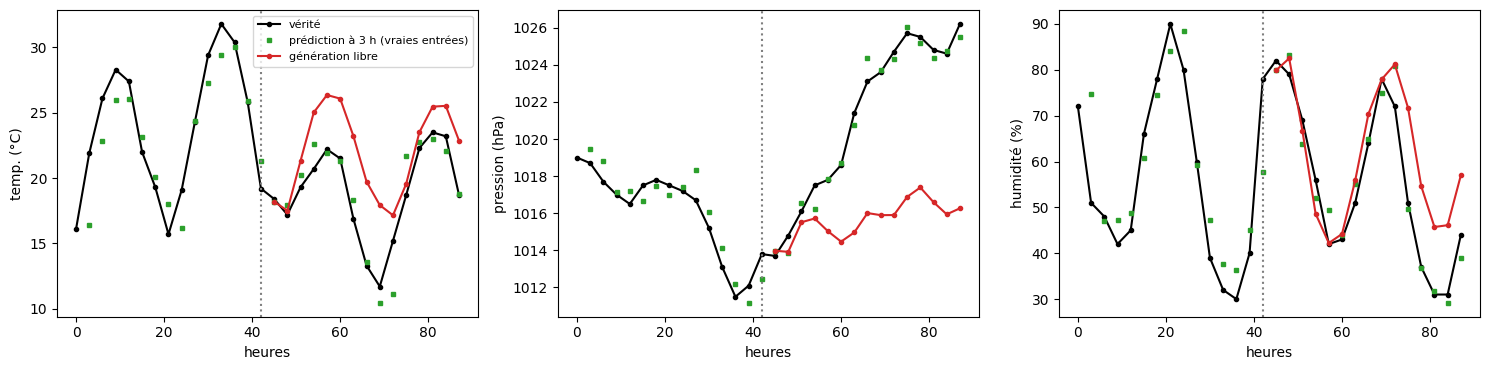

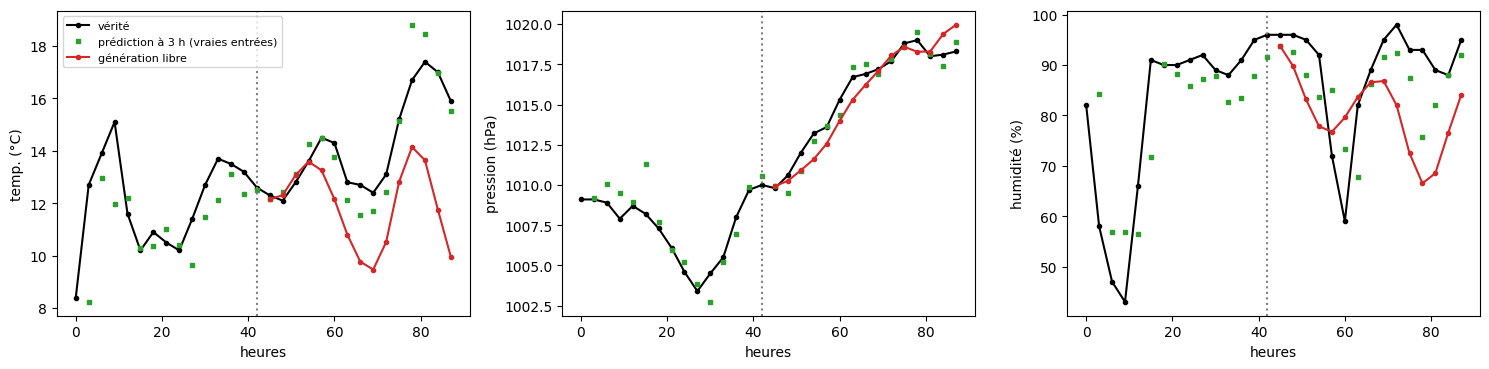

In [23]:
# An example: 15 steps read, then 15 steps generated, compared with the ground truth and the one-step predictions
def plot_example(model, win, label="free-running generation", i_vars=(4, 0, 6)):
    gen = model.generate(win[None, :N_CTX], N_GEN)[0]
    with th.no_grad():
        one_step, _ = model(win[None, :-1])
    truth_p, gen_p, one_p = to_physical(win).numpy(), to_physical(gen).numpy(), to_physical(one_step[0]).numpy()
    t = 3 * np.arange(N_CTX + N_GEN)
    fig, axes = plt.subplots(1, len(i_vars), figsize=(15, 3.8))
    for ax, k in zip(axes, i_vars):
        ax.plot(t, truth_p[:, k], "o-", color="k", ms=3, label="ground truth")
        ax.plot(t[1:], one_p[:, k], "s", color="C2", ms=3, label="3 h prediction (true inputs)")
        ax.plot(t[N_CTX:], gen_p[:, k], "o-", color="C3", ms=3, label=label)
        ax.axvline(t[N_CTX - 1], color="gray", ls=":")
        ax.set_xlabel("hours"); ax.set_ylabel(f"{short[k]} ({units[k]})")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for i in [40, 200]:
    plot_example(model, long_test[i])

**Long-term forecasting.** The `generate` method reads 15 true measurements (45 h), then generates the next 15 by feeding back its own predictions. It is evaluated on 1,862 test windows and compared with two baselines:
- **persistence**: repeat the last observed value;
- **daily persistence**: repeat the last observed day, which forecasts "tomorrow at 3 pm like today at 3 pm" and therefore captures the day-night cycle. It is a demanding baseline for temperature and humidity.

Errors are expressed in physical units (°C, hPa, %) after denormalization, so that they can be interpreted.

For the small model ($H = 10$), the error grows quickly with the horizon: temperature goes from 1.40 °C at 3 h to **3.13 °C at 24 h** and **4.56 °C at 45 h**. Beyond one day, it does **worse than daily persistence** (2.90 °C at 24 h, 3.72 °C at 45 h). For pressure, it remains slightly better than persistence (5.7 vs 6.2 hPa at 24 h). The examples show why: the generation reproduces the daily cycle well, but its amplitude and level drift, and a change in the pressure trend is not anticipated.

Two causes combine: a low-capacity model, and a training procedure in which it has never seen its own errors as inputs. During generation, each small error is fed back and accumulates (**exposure bias**). The next two sections address each cause in turn.

# Stronger models

---

## TODO
- [ ] try increasing the size of the hidden layer: H=20, 50, 100.
- [ ] run the full evaluation as before
- [ ] recurrent layers can also be stacked. Modify the class to allow stacking recurrent layers


--- H=20, 1 layer


--- H=50, 1 layer


--- H=100, 1 layer


--- H=50, 2 layers


,parameters,MSE valid,MSE test (3 h),temp. 3 h (°C),temp. 24 h (°C),temp. 45 h (°C),pressure 24 h (hPa)
model,,,,,,,
"H=10, 1 layer",647,0.238,0.227,1.404,3.128,4.556,5.725
"H=20, 1 layer",1887,0.219,0.212,1.305,2.855,4.011,5.699
"H=50, 1 layer",9207,0.213,0.205,1.288,2.743,3.647,5.527
"H=100, 1 layer",33407,0.217,0.207,1.263,2.672,3.483,5.572
"H=50, 2 layers",24507,0.212,0.203,1.274,2.783,3.686,5.885


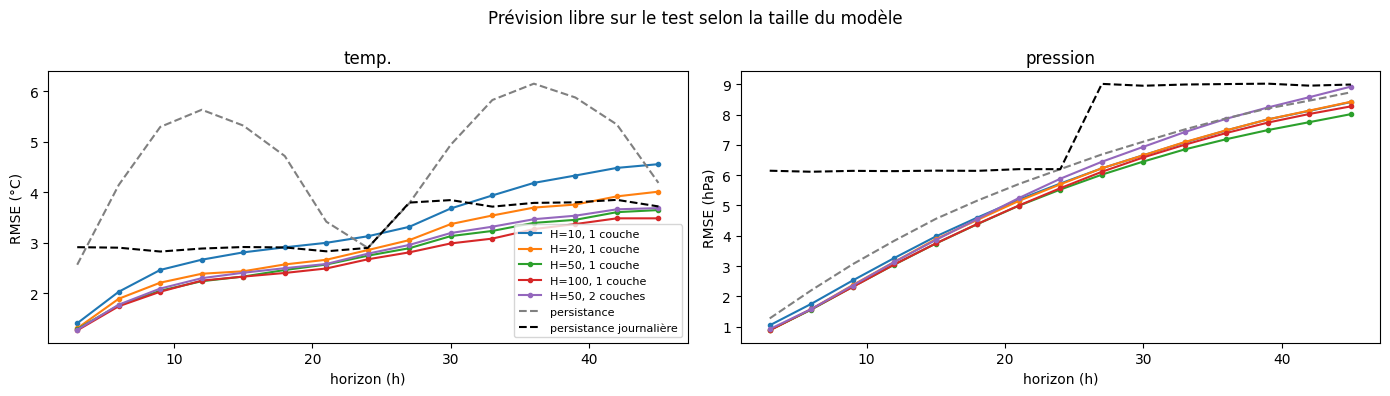

In [24]:
configs = [(10, 1), (20, 1), (50, 1), (100, 1), (50, 2)]
models, rows = {"H=10, 1 layer": model}, []
for H, nstack in configs:
    name = f"H={H}, {nstack} layer{'s' if nstack > 1 else ''}"
    if name not in models:
        th.manual_seed(1)
        m = GRUPredictor(hidden_dim=H, nstack=nstack, dropout=0.1 if nstack > 1 else 0)
        print(f"--- {name}")
        train_model(m, train_seq, valid_seq, epochs=30, lr=1e-3, verbose=False)
        models[name] = m
    m = models[name]
    r = free_run_rmse(m, long_test)
    rows.append({"model": name, "parameters": sum(p.numel() for p in m.parameters()),
                 "MSE valid": evaluate(m, valid_seq), "MSE test (3 h)": evaluate(m, test_seq),
                 "temp. 3 h (°C)": r[0, 4], "temp. 24 h (°C)": r[7, 4], "temp. 45 h (°C)": r[14, 4],
                 "pressure 24 h (hPa)": r[7, 0]})
    R[name] = r
results = pd.DataFrame(rows).set_index("model")
display(results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, k in zip(axes, [4, 0]):
    for name in models:
        ax.plot(hours, R[name][:, k], "o-", ms=3, label=name)
    for name in ["persistence", "daily persistence"]:
        ax.plot(hours, R[name][:, k], ls="--", color="gray" if name == "persistence" else "k", label=name)
    ax.set_xlabel("horizon (h)"); ax.set_ylabel(f"RMSE ({units[k]})"); ax.set_title(short[k])
axes[0].legend(fontsize=8)
plt.suptitle("Free-running forecast on the test set vs model size")
plt.tight_layout()
plt.show()

**Larger models.** The `GRUPredictor` class already handles stacking through the `nstack` parameter, passed to `num_layers` of `nn.GRU`, with dropout between layers.

- **At 3 h**, a larger size helps up to $H = 50$ (validation MSE from 0.238 to 0.213), then plateaus: $H = 100$ does no better (0.217), and two layers of 50 give the best score (0.212 in validation, 0.203 on the test set).
- **In the long term**, the gains are much clearer: the temperature error at 45 h drops from 4.56 °C ($H = 10$) to **3.48 °C** ($H = 100$), which beats daily persistence (3.72 °C) at every horizon.
- The best model at 3 h is **not** the best in free-running generation: the two-layer model ranks first at 3 h but only third at 45 h (3.69 °C). One-step error is therefore not a good criterion to choose a multi-step forecasting model.

# Improved training
When trying to predict beyond the next day, performance clearly drops.

---
## TODO
- [ ] propose and implement another training method.

**Proposed method: training on its own predictions (scheduled sampling with backpropagation through the generation).**

The model is trained with *teacher forcing*: at each step, it reads the true value. In free-running forecasting, on the contrary, it reads its own, slightly wrong predictions and ends up in situations it never saw during training; errors accumulate (this is *exposure bias*). To align training with usage:

1. we use longer sequences (30 steps): 15 steps read with the true values, then 15 steps where, at each step, the input is **its own prediction** with probability $p$, and the true value otherwise;
2. $p$ increases progressively from 0 to 1 over the epochs (*scheduled sampling*, Bengio et al., 2015): we start with teacher forcing and end with fully free-running generation;
3. the fed-back predictions are not detached from the graph: the gradient flows through the whole generation, so the model directly learns to limit the **multi-step** error, not just the 3 h error;
4. the best model is selected on the **free-running** forecast error in validation, since this is the error we want to reduce.

We start from the weights of the best teacher-forcing model (same architecture) and continue training with this method, to compare both at equal architecture.

In [25]:
def rollout(model, seqs, n_ctx, p_own):
    """Reads n_ctx true steps, then continues using its own prediction as input
    with probability p_own (the true value otherwise). Returns the predictions for steps 1..L-1."""
    preds_ctx, h = model(seqs[:, :n_ctx])
    preds = [preds_ctx]
    x_pred = preds_ctx[:, -1:]
    for t in range(n_ctx, seqs.shape[1] - 1):
        own = (th.rand(seqs.shape[0], 1, 1) < p_own)
        x_in = th.where(own, x_pred, seqs[:, t:t + 1])
        x_pred, h = model(x_in, h)
        preds.append(x_pred)
    return th.cat(preds, dim=1)

def free_run_score(model, wins):
    """Mean squared error (normalized) of the free-running forecast, over all horizons."""
    gen = model.generate(wins[:, :N_CTX], N_GEN)
    return F.mse_loss(gen, wins[:, N_CTX:N_CTX + N_GEN]).item()

def train_scheduled(model, train_seq, valid_wins, epochs=20, bsz=100, lr=5e-4, ramp=0.6):
    opt = optim.Adam(model.parameters(), lr=lr)
    best, best_state, hist = free_run_score(model, valid_wins), copy.deepcopy(model.state_dict()), []
    print(f"start (teacher forcing): free-running validation error {best:.4f}")
    t0 = time.time()
    for ep in range(epochs):
        p_own = min(1.0, ep / max(1, ramp * epochs))
        model.train()
        perm = th.randperm(len(train_seq))
        for i in range(0, len(train_seq), bsz):
            b = train_seq[perm[i:i + bsz]]
            loss = F.mse_loss(rollout(model, b, N_CTX, p_own), b[:, 1:])
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        score = free_run_score(model, valid_wins)
        hist.append(score)
        if score < best:
            best, best_state = score, copy.deepcopy(model.state_dict())
        print(f"epoch {ep + 1:2d} | p = {p_own:.2f} | free-running validation error {score:.4f} | {time.time() - t0:.0f} s")
    model.load_state_dict(best_state)
    return hist

# Data: windows of 30 steps (15 read + 15 to forecast)
train_long = make_sequences(Z_train[:cut], dates_train[:cut], L=N_CTX + N_GEN, stride=2)
valid_long = make_sequences(Z_train[cut:], dates_train[cut:], L=N_CTX + N_GEN, stride=4)
print("training windows:", tuple(train_long.shape), "| validation:", tuple(valid_long.shape))

best_name = results["MSE valid"].idxmin()
print("Starting point:", best_name)
th.manual_seed(1)
model_ss = copy.deepcopy(models[best_name])
hist_ss = train_scheduled(model_ss, train_long, valid_long, epochs=20)

training windows: (13198, 30, 7) | validation: (727, 30, 7)
Starting point: H=50, 2 layers
start (teacher forcing): free-running validation error 0.6155


epoch  1 | p = 0.00 | free-running validation error 0.6033 | 3 s


epoch  2 | p = 0.08 | free-running validation error 0.6091 | 6 s


epoch  3 | p = 0.17 | free-running validation error 0.6007 | 10 s


epoch  4 | p = 0.25 | free-running validation error 0.5960 | 13 s


...

epoch 16 | p = 1.00 | free-running validation error 0.5346 | 52 s


epoch 17 | p = 1.00 | free-running validation error 0.5454 | 55 s


epoch 18 | p = 1.00 | free-running validation error 0.5402 | 58 s


epoch 19 | p = 1.00 | free-running validation error 0.5352 | 62 s


epoch 20 | p = 1.00 | free-running validation error 0.5372 | 65 s


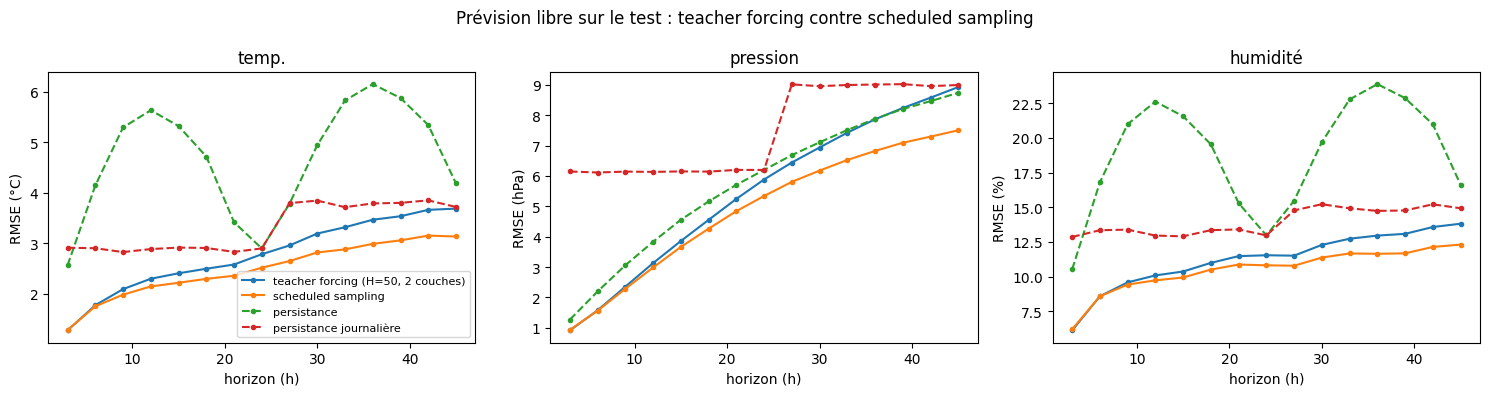

,teacher forcing,scheduled sampling
test MSE at 3 h (normalized),0.203,0.206
free-running test error (normalized),0.543,0.460
temp. 24 h (°C),2.783,2.516
temp. 45 h (°C),3.686,3.134
pressure 24 h (hPa),5.885,5.341
humidity 24 h (%),11.542,10.819


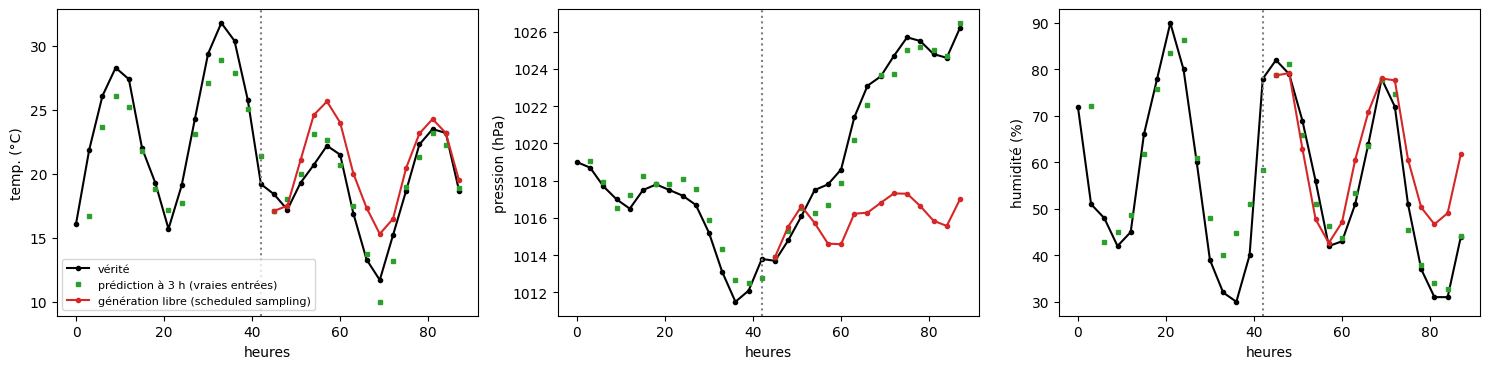

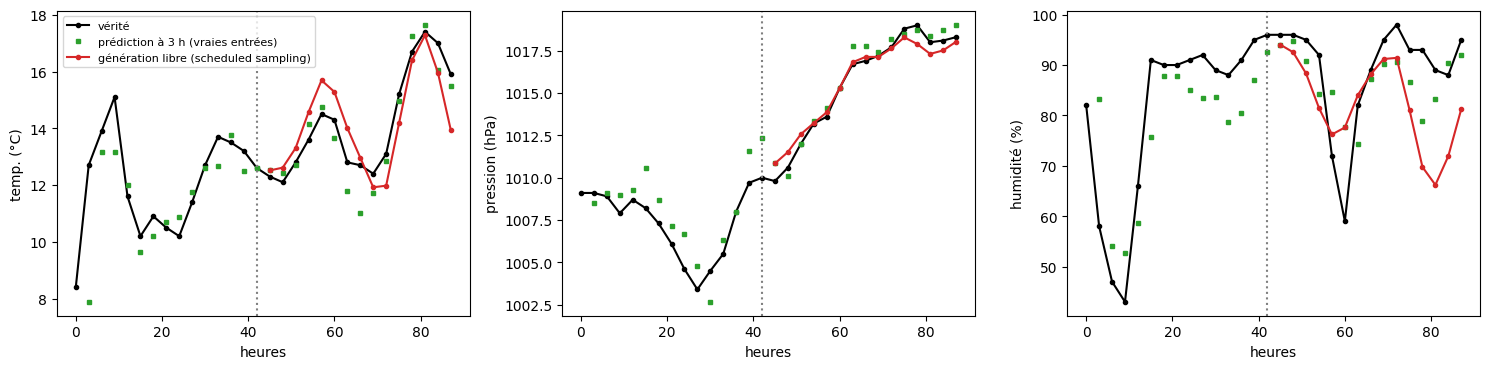

In [26]:
R["scheduled sampling"] = free_run_rmse(model_ss, long_test)
compare = {f"teacher forcing ({best_name})": R[best_name], "scheduled sampling": R["scheduled sampling"],
           "persistence": R["persistence"], "daily persistence": R["daily persistence"]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [4, 0, 6]):
    for name, r in compare.items():
        ax.plot(hours, r[:, k], marker="o", ms=3, label=name, ls="--" if "persistence" in name else "-")
    ax.set_xlabel("horizon (h)"); ax.set_ylabel(f"RMSE ({units[k]})"); ax.set_title(short[k])
axes[0].legend(fontsize=8)
plt.suptitle("Free-running forecast on the test set: teacher forcing vs scheduled sampling")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({name: {"test MSE at 3 h (normalized)": evaluate(m, test_seq),
                               "free-running test error (normalized)": free_run_score(m, long_test),
                               "temp. 24 h (°C)": R[key][7, 4], "temp. 45 h (°C)": R[key][14, 4],
                               "pressure 24 h (hPa)": R[key][7, 0], "humidity 24 h (%)": R[key][7, 6]}
                        for name, m, key in [("teacher forcing", models[best_name], best_name),
                                             ("scheduled sampling", model_ss, "scheduled sampling")]})
display(summary.round(3))

plot_example(model_ss, long_test[40], label="free-running generation (scheduled sampling)")
plot_example(model_ss, long_test[200], label="free-running generation (scheduled sampling)")

**Results.** We start from the two-layer model with 50 units (the best at 3 h in validation) and continue training for 20 epochs with scheduled sampling. The free-running validation error decreases steadily as $p$ increases, from 0.616 to 0.535.

On the test set, at equal architecture:
- the free-running forecast error (normalized, all horizons) drops from **0.543 to 0.460**, i.e. −15%;
- temperature at 24 h goes from 2.78 to **2.52 °C**, and at 45 h from 3.69 to **3.13 °C**. This beats every model trained with teacher forcing, including $H = 100$ (3.48 °C), and clearly beats daily persistence (3.72 °C);
- pressure at 24 h goes from 5.89 to 5.34 hPa, and humidity at 24 h from 11.5 to 10.8%.

The gain is zero at 3 h and grows with the horizon, exactly where the method acts. In return, the 3 h MSE degrades very slightly (0.203 to 0.206): the model gives up a little immediate accuracy to become robust to its own errors. One could object that the model was simply trained longer, but with teacher forcing the validation error had already plateaued at the end of training, and the gain concerns the multi-step error, not the 3 h error.

# Conclusion

- A GRU predicts the next measurement (3 h) well: the error is reduced by about 35% compared with persistence, mostly thanks to the daily cycle of temperature and humidity.
- The real difficulty is multi-step forecasting. With teacher forcing, a small model does worse than simply repeating the last observed day from 24 h onwards; more capacity ($H = 50$ or $100$) is needed to beat it.
- Training the model on its own predictions (scheduled sampling, with backpropagation through the generation) reduces the free-running forecast error by 15% at equal architecture, at a negligible cost at 3 h. It is the best approach tested: 2.5 °C temperature error at 24 h and 3.1 °C at 45 h.

**Possible improvements.** Encode wind direction as $(\cos\theta, \sin\theta)$; add the time of day and day of year as inputs, so that the model does not have to infer the day-night cycle from the sequence alone; read a context longer than 45 h; predict several horizons directly at once; or output a distribution rather than a single value, so as not to smooth out extremes.